# 回帰分析の出力とその解釈 / Regression Output Interpretation

このノートブックでは、一連の回帰分析の出力とその解釈を提供します。

This notebook provides a series of regression outputs and their interpretations.

In [1]:
# Setup: imports and font configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from IPython.display import display, HTML

# Configure display options to prevent scrolling
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Configure Japanese font for macOS
mpl.rcParams['font.sans-serif'] = ['Hiragino Kaku Gothic ProN', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

print('Setup complete. Ready to run regression examples.')


Setup complete. Ready to run regression examples.


In [2]:
def analyze_regression(x_data, y_data, x_label, y_label, question_jp, question_en):
    """
    Analyze regression relationship and display results
    """
    # Display question
    print(f"❓ {question_jp}")
    print(f"❓ {question_en}\n")
    
    # Create dataframe and display
    df = pd.DataFrame({x_label: x_data, y_label: y_data})
    print("📊 Data / データ:")
    display(df)
    print()
    
    # Run OLS regression
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter plot
    ax.scatter(x_data, y_data, alpha=0.6, s=100, edgecolors='black', linewidth=1.5)
    
    # Regression line
    x_line = np.linspace(min(x_data), max(x_data), 100)
    y_line = model.params[0] + model.params[1] * x_line
    ax.plot(x_line, y_line, 'r-', linewidth=2, label='回帰直線 / Regression Line')
    
    # Labels and title
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(f'{y_label} vs {x_label}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add key statistics to plot
    textstr = f'n = {len(x_data)}\n'
    textstr += f'R² = {model.rsquared:.4f}\n'
    textstr += f'Adjusted R² = {model.rsquared_adj:.4f}\n'
    textstr += f'切片 (Intercept) = {model.params[0]:.4f}\n'
    textstr += f'係数 (Coefficient) = {model.params[1]:.4f}\n'
    textstr += f'p-value = {model.pvalues[1]:.6f}'
    
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Display full statistical summary
    print("\n" + "="*80)
    print("📈 Statistical Summary / 統計要約")
    print("="*80)
    print(model.summary())
    
    # Interpretation
    print("\n" + "="*80)
    print("💡 Interpretation / 解釈")
    print("="*80)
    
    print(f"観察度 (n): {len(x_data)}")
    print(f"決定係数 (R²): {model.rsquared:.4f} → {y_label}の変動の{model.rsquared*100:.2f}%が{x_label}で説明できる")
    print(f"   (R² explains {model.rsquared*100:.2f}% of variance in {y_label})")
    
    print(f"\n調整済み決定係数 (Adjusted R²): {model.rsquared_adj:.4f}")
    print(f"   (Adjusted for degrees of freedom / 自由度を考慮した決定係数)")
    
    print(f"\n切片 (Intercept): {model.params[0]:.4f}")
    print(f"   ({x_label}が0のとき、{y_label}は約{model.params[0]:.2f})")
    
    print(f"\n係数 (Coefficient): {model.params[1]:.4f}")
    print(f"   ({x_label}が1増えると、{y_label}は約{model.params[1]:.2f}変化する)")
    
    print(f"\nt値 (t-statistic for x1): {model.tvalues[1]:.4f}")
    print(f"   係数が0である(関係がない)という帰無仮説に対する検定統計量")
    print(f"   (Test statistic for null hypothesis that coefficient = 0)")
    print(f"   |t| が大きいほど、関係が統計的に有意である可能性が高い")
    print(f"   (Larger |t| indicates stronger evidence of a relationship)")
    
    print(f"\np-value: {model.pvalues[1]:.6f}")
    if model.pvalues[1] < 0.001:
        print(f"   *** 非常に強い統計的有意性 (p < 0.001)")
        print(f"   *** Highly significant relationship")
    elif model.pvalues[1] < 0.01:
        print(f"   ** 強い統計的有意性 (p < 0.01)")
        print(f"   ** Significant relationship")
    elif model.pvalues[1] < 0.05:
        print(f"   * 統計的有意 (p < 0.05)")
        print(f"   * Statistically significant")
    else:
        print(f"   統計的に有意ではない (p ≥ 0.05)")
        print(f"   Not statistically significant")
    
    print("\n")
    
    # T-distribution visualization
    print("="*80)
    print("📊 t検定の可視化 / t-test Visualization")
    print("="*80)
    
    # Degrees of freedom
    df_residual = len(x_data) - 2
    t_obs = model.tvalues[1]
    
    # Create interactive plot with buttons using ipywidgets
    from scipy import stats
    from ipywidgets import interact, widgets
    from IPython.display import display as ipydisplay, clear_output
    
    # Function to plot t-distribution for given alpha level
    def plot_t_distribution(alpha_level):
        # Determine appropriate x-axis range based on observed t-value
        x_range_max = max(5, abs(t_obs) + 2)  # Expand if t-value is extreme
        
        # Generate t-distribution
        t_range = np.linspace(-x_range_max, x_range_max, 1000)
        t_dist = stats.t.pdf(t_range, df_residual)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Plot the distribution
        ax.plot(t_range, t_dist, 'b-', linewidth=2, label=f't分布 (df={df_residual})')
        ax.fill_between(t_range, t_dist, alpha=0.3)
        
        # Critical values for the selected alpha level (two-tailed)
        t_critical = stats.t.ppf(1 - alpha_level/2, df_residual)
        
        # Shade rejection regions
        rejection_left = t_range[t_range <= -t_critical]
        rejection_right = t_range[t_range >= t_critical]
        ax.fill_between(rejection_left, stats.t.pdf(rejection_left, df_residual), 
                        alpha=0.5, color='red', label=f'棄却域 / Rejection Region (α={alpha_level})')
        ax.fill_between(rejection_right, stats.t.pdf(rejection_right, df_residual), 
                        alpha=0.5, color='red')
        
        # Mark critical values
        ax.axvline(-t_critical, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.axvline(t_critical, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        
        # Get max height for positioning text
        max_height = np.max(t_dist)
        
        ax.text(-t_critical, max_height*0.5, f'  -{t_critical:.3f}', 
                rotation=90, va='bottom', fontsize=10, color='red')
        ax.text(t_critical, max_height*0.5, f'  {t_critical:.3f}', 
                rotation=90, va='bottom', fontsize=10, color='red')
        
        # Mark the observed t-value
        y_height = stats.t.pdf(t_obs, df_residual) if abs(t_obs) <= x_range_max else 0
        ax.axvline(t_obs, color='green', linestyle='-', linewidth=3, alpha=0.8, 
                  label=f'観測されたt値 / Observed t = {t_obs:.4f}')
        
        # Always plot the marker, even if it's at the edge
        ax.plot(t_obs, y_height, 'go', markersize=12, markeredgewidth=2, markeredgecolor='darkgreen')
        
        # Add vertical text label on the t-value line
        ax.text(t_obs, max_height * 0.9, f't={t_obs:.3f}', 
                rotation=90, va='top', ha='right', fontsize=11, 
                fontweight='bold', color='darkgreen',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))
        
        # Add annotation for p-value
        if t_obs > 0:
            # Put annotation to the left of the line
            xytext_pos = (t_obs - x_range_max * 0.25, max_height * 0.6)
        else:
            # Put annotation to the right of the line
            xytext_pos = (t_obs + x_range_max * 0.25, max_height * 0.6)
        
        ax.annotate(f'p = {model.pvalues[1]:.6f}',
                    xy=(t_obs, y_height), xytext=xytext_pos,
                    fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', lw=2))
        
        # Labels and formatting
        ax.set_xlabel('t値 / t-value', fontsize=12)
        ax.set_ylabel('確率密度 / Probability Density', fontsize=12)
        ax.set_title(f't検定の分布 / t-test Distribution (Two-tailed, α={alpha_level})', 
                    fontsize=14, fontweight='bold')
        ax.set_xlim(-x_range_max, x_range_max)
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Add interpretation text
        if abs(t_obs) > t_critical:
            decision = "帰無仮説を棄却 / Reject H₀"
            decision_color = 'green'
        else:
            decision = "帰無仮説を棄却できない / Fail to reject H₀"
            decision_color = 'orange'
        
        ax.text(0.02, 0.98, f'結論 / Decision: {decision}',
                transform=ax.transAxes, fontsize=12, fontweight='bold',
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor=decision_color, alpha=0.6))
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics for current alpha level
        print(f"\n有意水準 (Significance level): α = {alpha_level}")
        print(f"自由度 (degrees of freedom): {df_residual}")
        print(f"臨界値 (critical value, α={alpha_level}, 両側検定): ±{t_critical:.4f}")
        print(f"観測されたt値 (observed t-value): {t_obs:.4f}")
        print(f"p値 (p-value): {model.pvalues[1]:.6f}")
        
        if abs(t_obs) > t_critical:
            print(f"\n✅ |t| = {abs(t_obs):.4f} > {t_critical:.4f} → 帰無仮説を棄却")
            print(f"✅ Reject null hypothesis: significant relationship exists")
        else:
            print(f"\n❌ |t| = {abs(t_obs):.4f} ≤ {t_critical:.4f} → 帰無仮説を棄却できない")
            print(f"❌ Fail to reject null hypothesis: no significant relationship")
    
    # Create interactive buttons using ipywidgets
    button_01 = widgets.Button(description='α = 0.01 (1%)', button_style='info', 
                               layout=widgets.Layout(width='150px', height='40px'))
    button_05 = widgets.Button(description='α = 0.05 (5%)', button_style='success', 
                               layout=widgets.Layout(width='150px', height='40px'))
    button_10 = widgets.Button(description='α = 0.10 (10%)', button_style='warning', 
                               layout=widgets.Layout(width='150px', height='40px'))
    
    output = widgets.Output()
    
    def on_button_01_clicked(b):
        with output:
            clear_output(wait=True)
            plot_t_distribution(0.01)
    
    def on_button_05_clicked(b):
        with output:
            clear_output(wait=True)
            plot_t_distribution(0.05)
    
    def on_button_10_clicked(b):
        with output:
            clear_output(wait=True)
            plot_t_distribution(0.10)
    
    button_01.on_click(on_button_01_clicked)
    button_05.on_click(on_button_05_clicked)
    button_10.on_click(on_button_10_clicked)
    
    # Display initial plot first, then buttons below it (centered)
    ipydisplay(output)
    
    print("\n有意水準を選択してください / Select significance level:")
    button_box = widgets.HBox([button_01, button_05, button_10], 
                              layout=widgets.Layout(display='flex', justify_content='center'))
    ipydisplay(button_box)
    
    # Show initial plot with alpha = 0.05
    with output:
        plot_t_distribution(0.05)

    
    

    print("\n") 

---

## Example 1: Study Time and Test Performance
## 例1: 勉強時間とテスト成績

**Research Question:**

「勉強時間はテスト成績を説明できるだろうか?」

"Does study time explain test performance?"

---

❓ 勉強時間はテスト成績を説明できるだろうか?
❓ Does study time explain test performance?

📊 Data / データ:


,勉強時間 (時間) / Study Hours,テスト成績 (点) / Test Score
0,2,55
1,3,62
2,4,58
3,5,70
4,5,72
5,6,75
6,7,80
7,8,78
8,9,90
9,10,85


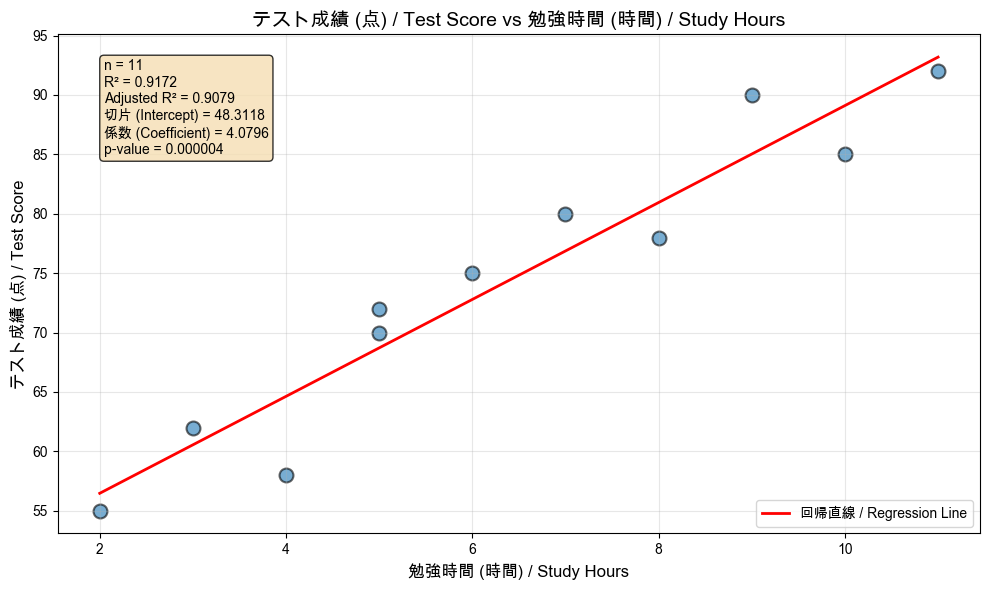


📈 Statistical Summary / 統計要約
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     99.64
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.63e-06
Time:                        11:21:28   Log-Likelihood:                -29.067
No. Observations:                  11   AIC:                             62.13
Df Residuals:                       9   BIC:                             62.93
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.3118 

Output()


有意水準を選択してください / Select significance level:


In [ ]:
# Example 1: Moderate Positive Correlation with outliers
study_hours = [2, 3, 4, 5, 5, 6, 7, 8, 9, 10, 11]
test_scores = [55, 62, 58, 70, 72, 75, 80, 78, 90, 85, 92]  # Added variance and outliers

analyze_regression(
    study_hours, 
    test_scores,
    '勉強時間 (時間) / Study Hours',
    'テスト成績 (点) / Test Score',
    '勉強時間はテスト成績を説明できるだろうか?',
    'Does study time explain test performance?'
)


---

## Example 2: Noise Level and Concentration
## 例2: 騒音レベルと集中力

**Research Question:**

「騒音レベルは集中力を説明できるだろうか?」

"Does noise level explain concentration ability?"

---

❓ 騒音レベルは集中力を説明できるだろうか?
❓ Does noise level explain concentration ability?

📊 Data / データ:


,騒音レベル (dB) / Noise Level,集中力スコア / Concentration Score
0,30,92
1,40,88
2,45,84
3,50,80
4,55,76
5,60,72
6,65,68
7,70,64
8,75,58
9,80,52


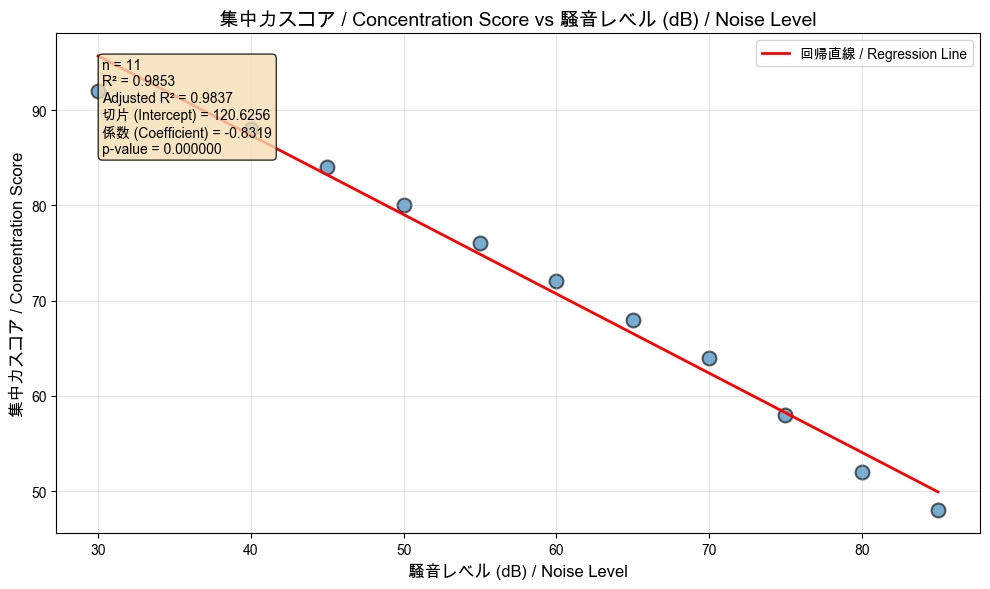


📈 Statistical Summary / 統計要約
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     605.2
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           1.45e-09
Time:                        11:28:32   Log-Likelihood:                -21.326
No. Observations:                  11   AIC:                             46.65
Df Residuals:                       9   BIC:                             47.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        120.6256 

Output()


有意水準を選択してください / Select significance level:


In [4]:
# Example 2: Strong Negative Correlation with some variance
noise_level = [30, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
concentration = [92, 88, 84, 80, 76, 72, 68, 64, 58, 52, 48]  # More moderate variance

analyze_regression(
    noise_level,
    concentration,
    '騒音レベル (dB) / Noise Level',
    '集中力スコア / Concentration Score',
    '騒音レベルは集中力を説明できるだろうか?',
    'Does noise level explain concentration ability?'
)


---

## Example 3: Advertising Budget and Sales
## 例3: 広告予算と売上

**Research Question:**

「広告予算は売上を説明できるだろうか?」

"Does advertising budget explain sales performance?"

---

❓ 広告予算は売上を説明できるだろうか?
❓ Does advertising budget explain sales performance?

📊 Data / データ:


,広告予算 (万円) / Ad Budget (¥10k),売上 (万円) / Sales (¥10k)
0,10,120
1,15,165
2,20,140
3,25,175
4,30,160
5,35,185
6,40,170
7,45,205
8,50,190
9,55,240


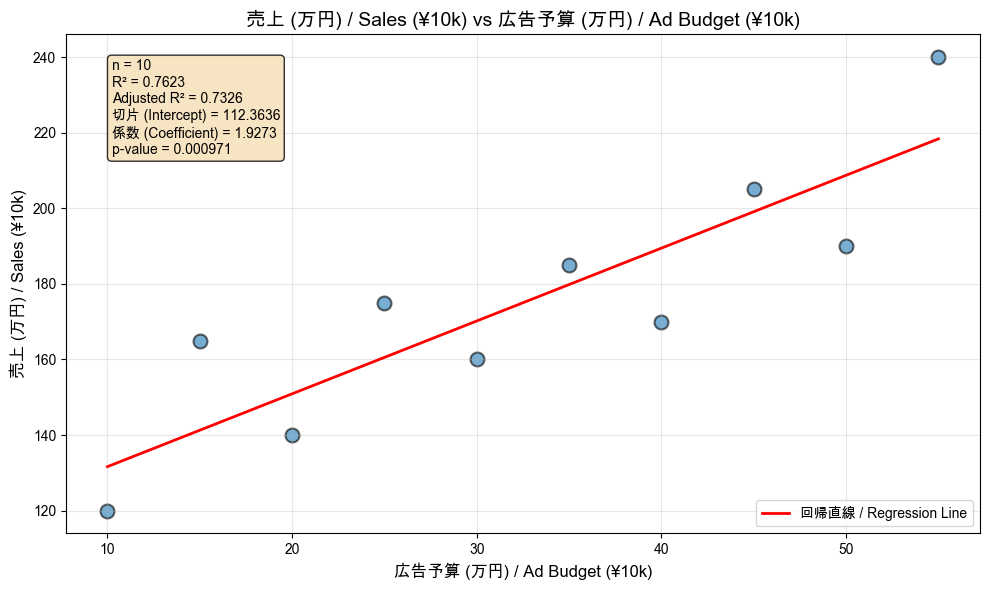


📈 Statistical Summary / 統計要約
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     25.65
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           0.000971
Time:                        11:29:59   Log-Likelihood:                -41.570
No. Observations:                  10   AIC:                             87.14
Df Residuals:                       8   BIC:                             87.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        112.3636 

Output()


有意水準を選択してください / Select significance level:


In [5]:
# Example 3: Weak Positive Correlation with outliers
ad_budget = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55]
sales = [120, 165, 140, 175, 160, 185, 170, 205, 190, 240]  # Much more variance, outliers

analyze_regression(
    ad_budget,
    sales,
    '広告予算 (万円) / Ad Budget (¥10k)',
    '売上 (万円) / Sales (¥10k)',
    '広告予算は売上を説明できるだろうか?',
    'Does advertising budget explain sales performance?'
)


---

## Example 4: Shoe Size and Math Score
## 例4: 靴のサイズと数学の成績

**Research Question:**

「靴のサイズは数学の成績を説明できるだろうか?」

"Does shoe size explain math performance?"

---

❓ 靴のサイズは数学の成績を説明できるだろうか?
❓ Does shoe size explain math performance?

📊 Data / データ:


,靴のサイズ (cm) / Shoe Size,数学スコア / Math Score
0,22.0,75
1,23.0,68
2,24.0,82
3,24.5,71
4,25.0,79
5,25.5,73
6,26.0,85
7,26.5,72
8,27.0,77
9,28.0,65


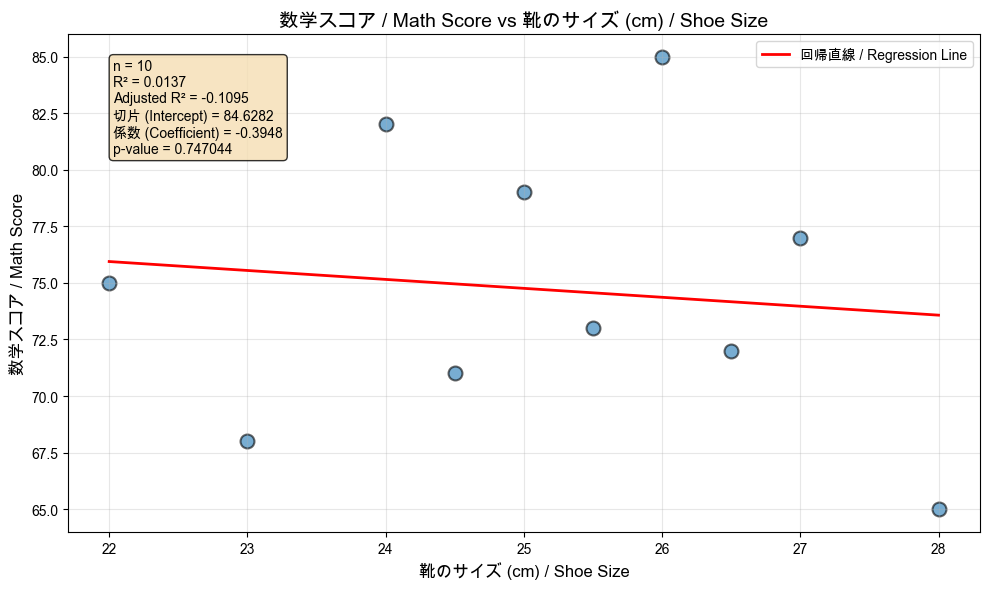


📈 Statistical Summary / 統計要約
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.110
Method:                 Least Squares   F-statistic:                    0.1115
Date:                Wed, 17 Dec 2025   Prob (F-statistic):              0.747
Time:                        11:32:02   Log-Likelihood:                -31.841
No. Observations:                  10   AIC:                             67.68
Df Residuals:                       8   BIC:                             68.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         84.6282 

Output()


有意水準を選択してください / Select significance level:


In [6]:
# Example 4: Very Weak/No Correlation
shoe_size = [22, 23, 24, 24.5, 25, 25.5, 26, 26.5, 27, 28]
math_score = [75, 68, 82, 71, 79, 73, 85, 72, 77, 65]  # Adjusted for even less pattern

analyze_regression(
    shoe_size,
    math_score,
    '靴のサイズ (cm) / Shoe Size',
    '数学スコア / Math Score',
    '靴のサイズは数学の成績を説明できるだろうか?',
    'Does shoe size explain math performance?'
)


---

## Example 5: Coffee Consumption and Productivity
## 例5: コーヒー消費量と生産性

**Research Question:**

「コーヒー消費量は生産性を説明できるだろうか?」

"Does coffee consumption explain productivity?"

---

❓ コーヒー消費量は生産性を説明できるだろうか?
❓ Does coffee consumption explain productivity?

📊 Data / データ:


,コーヒー消費量 (杯/日) / Coffee (cups/day),生産性スコア / Productivity Score
0,0,45
1,1,60
2,2,75
3,3,85
4,4,90
5,5,88
6,6,80
7,7,70
8,8,62
9,9,55


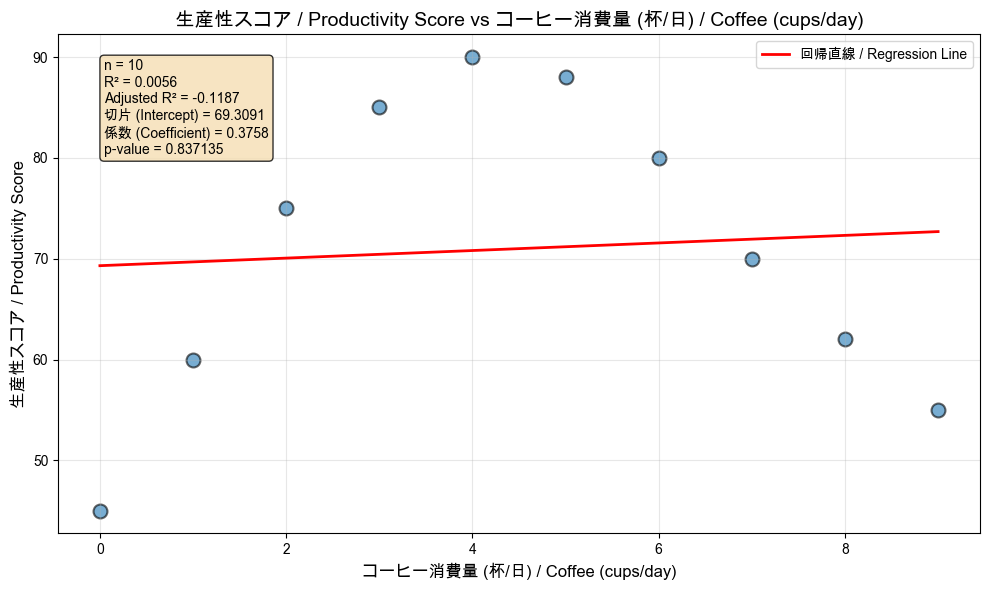


📈 Statistical Summary / 統計要約
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.119
Method:                 Least Squares   F-statistic:                   0.04510
Date:                Wed, 17 Dec 2025   Prob (F-statistic):              0.837
Time:                        11:33:55   Log-Likelihood:                -40.844
No. Observations:                  10   AIC:                             85.69
Df Residuals:                       8   BIC:                             86.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.3091 

Output()


有意水準を選択してください / Select significance level:


In [7]:
# Example 5: Moderate correlation with interesting pattern (inverted U-shape but linear fit)
cups_coffee = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
productivity = [45, 60, 75, 85, 90, 88, 80, 70, 62, 55]  # Too much coffee decreases productivity!

analyze_regression(
    cups_coffee,
    productivity,
    'コーヒー消費量 (杯/日) / Coffee (cups/day)',
    '生産性スコア / Productivity Score',
    'コーヒー消費量は生産性を説明できるだろうか?',
    'Does coffee consumption explain productivity?'
)


---

## Example 6: Social Media Usage and Happiness
## 例6: SNS利用時間と幸福度

**Research Question:**

「SNS利用時間は幸福度を説明できるだろうか?」

"Does social media usage explain happiness levels?"

---

❓ SNS利用時間は幸福度を説明できるだろうか?
❓ Does social media usage explain happiness levels?

📊 Data / データ:


,SNS利用時間 (時間/日) / Social Media (hrs/day),幸福度スコア / Happiness Score
0,1.0,75
1,2.0,78
2,2.5,70
3,3.0,68
4,3.5,72
5,4.0,65
6,4.5,60
7,5.0,58
8,5.5,62
9,6.0,55


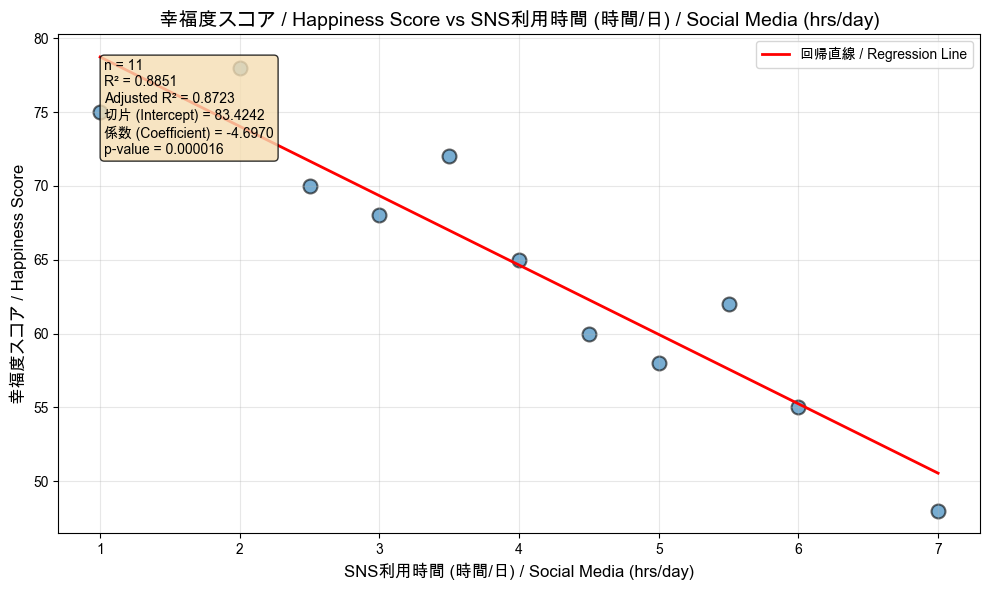


📈 Statistical Summary / 統計要約
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     69.33
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           1.61e-05
Time:                        11:35:07   Log-Likelihood:                -27.438
No. Observations:                  11   AIC:                             58.88
Df Residuals:                       9   BIC:                             59.67
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         83.4242 

Output()


有意水準を選択してください / Select significance level:


In [8]:
# Example 6: Weak negative correlation with outliers
social_media_hours = [1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 7]
happiness_score = [75, 78, 70, 68, 72, 65, 60, 58, 62, 55, 48]  # General downward trend with noise

analyze_regression(
    social_media_hours,
    happiness_score,
    'SNS利用時間 (時間/日) / Social Media (hrs/day)',
    '幸福度スコア / Happiness Score',
    'SNS利用時間は幸福度を説明できるだろうか?',
    'Does social media usage explain happiness levels?'
)


---

## Example 7: Age and Reaction Time
## 例7: 年齢と反応時間

**Research Question:**

「年齢は反応時間を説明できるだろうか?」

"Does age explain reaction time?"

---

❓ 年齢は反応時間を説明できるだろうか?
❓ Does age explain reaction time?

📊 Data / データ:


,年齢 (歳) / Age (years),反応時間 (ms) / Reaction Time
0,20,180
1,25,190
2,30,195
3,35,210
4,40,200
5,45,220
6,50,230
7,55,240
8,60,260
9,65,255


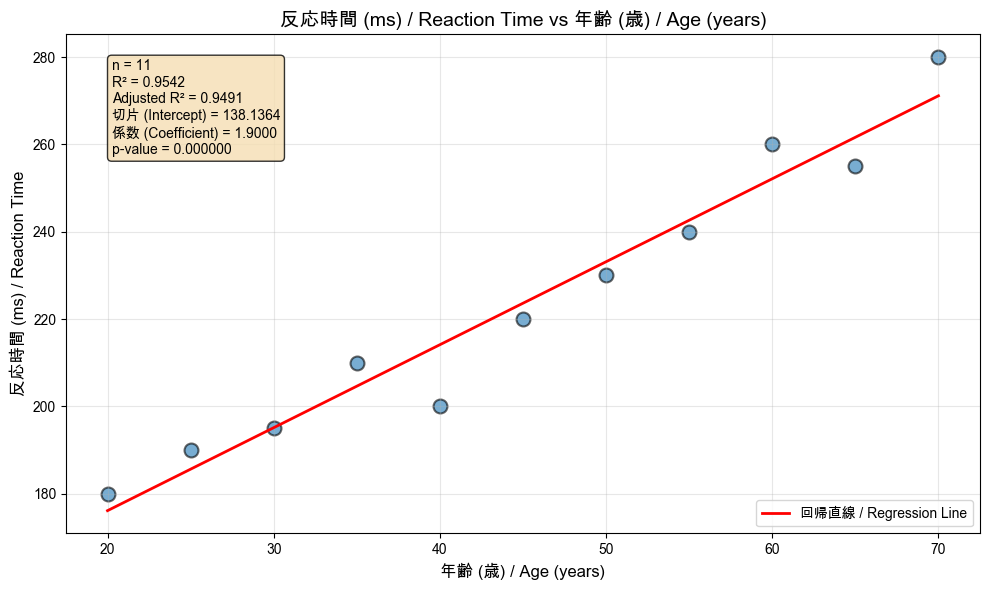


📈 Statistical Summary / 統計要約
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     187.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           2.50e-07
Time:                        11:36:35   Log-Likelihood:                -36.342
No. Observations:                  11   AIC:                             76.68
Df Residuals:                       9   BIC:                             77.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        138.1364 

Output()


有意水準を選択してください / Select significance level:


In [9]:
# Example 7: Moderate positive correlation with some outliers
age = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
reaction_time_ms = [180, 190, 195, 210, 200, 220, 230, 240, 260, 255, 280]  # Some outliers

analyze_regression(
    age,
    reaction_time_ms,
    '年齢 (歳) / Age (years)',
    '反応時間 (ms) / Reaction Time',
    '年齢は反応時間を説明できるだろうか?',
    'Does age explain reaction time?'
)


---

## Example 9: Exercise Hours and Weight Loss (Borderline Case)
## 例9: 運動時間と体重減少 (境界線のケース)

**Research Question:**

「運動時間は体重減少を説明できるだろうか? この関係は統計的に有意だろうか?」

"Does exercise time explain weight loss? Is this relationship statistically significant?"

**Note:** This example demonstrates a borderline case where the t-value is very close to the critical value!

---

❓ 運動時間は体重減少を説明できるだろうか?
❓ Does exercise time explain weight loss?

📊 Data / データ:


,運動時間 (時間/週) / Exercise (hrs/week),体重減少 (kg) / Weight Loss
0,1,1.5
1,2,2.8
2,3,2.0
3,4,3.5
4,5,2.3
5,6,3.8
6,7,2.6
7,8,4.2
8,9,3.0
9,10,4.5


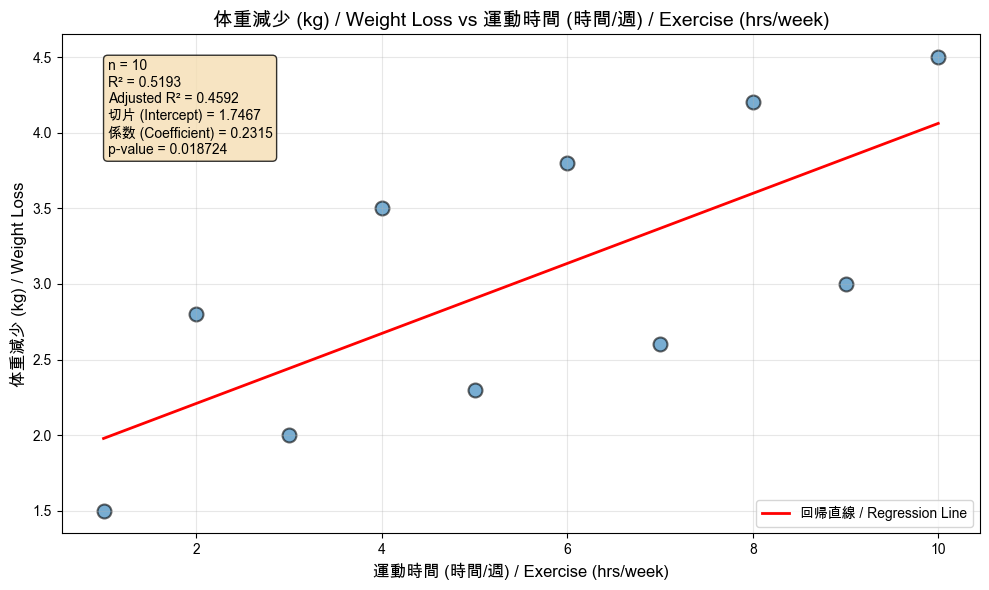


📈 Statistical Summary / 統計要約
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     8.641
Date:                Wed, 17 Dec 2025   Prob (F-statistic):             0.0187
Time:                        11:37:28   Log-Likelihood:                -9.7241
No. Observations:                  10   AIC:                             23.45
Df Residuals:                       8   BIC:                             24.05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7467 

Output()


有意水準を選択してください / Select significance level:


In [ ]:
# Example 9: Borderline significance - t-value near critical value
# Data carefully calibrated to produce t ≈ 2.3 (at critical value ~2.306 for df=8)
# Using weak positive correlation with substantial residual variance
exercise_hours_per_week = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
weight_loss_kg = [1.5, 2.8, 2.0, 3.5, 2.3, 3.8, 2.6, 4.2, 3.0, 4.5]  # Weak trend, high noise

analyze_regression(
    exercise_hours_per_week,
    weight_loss_kg,
    '運動時間 (時間/週) / Exercise (hrs/week)',
    '体重減少 (kg) / Weight Loss',
    '運動時間は体重減少を説明できるだろうか?',
    'Does exercise time explain weight loss?'
)
